# Stock Trend Predictor — Analysis Notebook

This notebook documents the full development process: data loading, feature engineering, model training, evaluation, and backtesting.
It was written after the fact as a clean record of what was built and why.

## 1. Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

pd.set_option('display.precision', 3)
np.random.seed(42)

## 2. Load Data

AAPL daily OHLCV data from 2021 to 2026, downloaded via yfinance and saved locally.

In [12]:
# To re-download fresh data:
# import yfinance as yf
# df = yf.download('AAPL', start='2021-03-25', end='2026-03-25')
# df.to_csv('aapl_data.csv')

df = pd.read_csv('aapl_data.csv', sep=',', skiprows=[1, 2])
df.rename(columns={'Price': 'Date'}, inplace=True)
print(f'Loaded {len(df)} rows from {df["Date"].iloc[0]} to {df["Date"].iloc[-1]}')
df.head()

Loaded 1255 rows from 2021-03-25 to 2026-03-24


,Date,Close,High,Low,Open,Volume
0,2021-03-25,117.454,118.496,115.905,116.431,98844700
1,2021-03-26,118.058,118.321,115.828,117.220,94071200
2,2021-03-29,118.233,119.392,117.591,118.487,80819200
3,2021-03-30,116.782,117.269,115.769,116.987,85671900
4,2021-03-31,118.974,120.308,118.000,118.487,118323800


## 3. Feature Engineering

Rather than feeding raw prices to the model, we compute technical indicators that traders actually use.
Each feature captures a different aspect of price behavior.

*During development I experimented with several feature combinations including volume percent change, 3-day mean return, and various window sizes for volatility. I also compared unweighted vs class-balanced logistic regression. The final feature set was chosen based on cross-validation stability rather than single-split accuracy, after discovering that results varied significantly between runs without a fixed random seed.*


| Feature | Window | What it captures |
|---|---|---|
| Lagged returns | 3 days | Recent momentum |
| Volatility | 3 and 5 days | Short-term market nervousness |
| SMA crossover | 5 vs 20 days | Is the trend bullish or bearish? |
| RSI | 14 days | Is the stock overbought or oversold? |
| Price position | 10 days | Where is price in its recent range? |
| Price deviation | 3 days | Short-term displacement from mean |

In [13]:
df['prev_close'] = df['Close'].shift(1)
df['returns'] = (df['Close'] - df['prev_close']) / df['prev_close']

# Rolling volatility
df['volatility_3'] = df['returns'].rolling(3).std()
df['volatility_5'] = df['returns'].rolling(5).std()

# SMA crossover: 1 = short-term trend above long-term (bullish), 0 = bearish
df['sma_5'] = df['Close'].rolling(5).mean()
df['sma_20'] = df['Close'].rolling(20).mean()
df['sma_crossover'] = (df['sma_5'] > df['sma_20']).astype(int)

# RSI (14-period)
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain / (loss + 1e-9)
df['rsi'] = 100 - (100 / (1 + rs))

# Price position in 10-day range (0 = near low, 1 = near high)
df['high_10'] = df['Close'].rolling(10).max()
df['low_10'] = df['Close'].rolling(10).min()
df['price_position'] = (df['Close'] - df['low_10']) / (df['high_10'] - df['low_10'] + 1e-9)

df = df.dropna().reset_index(drop=True)
print(f'{len(df)} rows after dropping NaNs from rolling windows')
df[['Close', 'returns', 'volatility_5', 'rsi', 'price_position', 'sma_crossover']].head()

1236 rows after dropping NaNs from rolling windows


,Close,returns,volatility_5,rsi,price_position,sma_crossover
0,128.509,-0.012,0.008,68.230,0.194,1
1,130.827,0.018,0.013,67.542,0.856,1
2,131.217,0.003,0.013,67.663,0.959,1
3,130.895,-0.002,0.011,64.276,0.845,1
4,130.106,-0.006,0.011,57.638,0.566,1


### Build X and y

For each day `i`, we build a feature vector from the last 3 days and predict whether tomorrow's close will be higher than today's.

In [14]:
return_l = df['returns'].tolist()
close_l = df['Close'].tolist()
vol3_l = df['volatility_3'].tolist()
vol5_l = df['volatility_5'].tolist()
rsi_l = df['rsi'].tolist()
sma_l = df['sma_crossover'].tolist()
pp_l = df['price_position'].tolist()

X, y = [], []

for i in range(2, len(return_l) - 1):
    f = [
        return_l[i-2], return_l[i-1], return_l[i],
        close_l[i] - np.mean([close_l[i-2], close_l[i-1], close_l[i]]),
        vol3_l[i], vol5_l[i],
        rsi_l[i], sma_l[i], pp_l[i]
    ]
    X.append(f)
    y.append(int(close_l[i+1] >= close_l[i]))

X = np.array(X)
y = np.array(y)

print(f'X shape: {X.shape}')
print(f'Class balance — Up: {y.sum()}, Down: {(y==0).sum()}')

X shape: (1233, 9)
Class balance — Up: 654, Down: 579


## 4. Train / Test Split and Scaling

We use a chronological split (no shuffling) to respect the time series nature of the data.
Shuffling would leak future information into training, giving misleadingly good results.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

Training samples: 986
Test samples: 247


## 5. Model Training

Logistic Regression with `class_weight='balanced'` to account for any class imbalance,
and `random_state=42` for reproducibility.

In [16]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)
print('Model trained.')

Model trained.


## 6. Evaluation

Accuracy alone is misleading on financial data. We use a fuller picture:
- **Accuracy**: overall correct predictions
- **Precision**: when the model says UP, how often is it right?
- **Recall**: of all actual UP days, how many did it catch?
- **ROC-AUC**: how well can it rank predictions? (0.5 = random, 1.0 = perfect)

In [17]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.5182
ROC-AUC:   0.5218

              precision    recall  f1-score   support

        Down       0.49      0.47      0.48       117
          Up       0.54      0.56      0.55       130

    accuracy                           0.52       247
   macro avg       0.52      0.52      0.52       247
weighted avg       0.52      0.52      0.52       247

Confusion Matrix:
[[55 62]
 [57 73]]


### Cross-Validation

A single train/test split can be lucky or unlucky. Cross-validation gives a more reliable estimate
by averaging over multiple splits. The `+/-` value shows how stable the results are.

In [18]:
cv_model = LogisticRegression(class_weight='balanced', random_state=42)
scores = cross_val_score(cv_model, X, y, cv=5, scoring='accuracy')
print(f'Cross-validation accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')
print(f'Individual folds: {[round(s, 4) for s in scores]}')

Cross-validation accuracy: 0.4769 (+/- 0.0436)
Individual folds: [np.float64(0.5142), np.float64(0.4372), np.float64(0.4291), np.float64(0.4634), np.float64(0.5407)]


### What these results mean

Cross-validation accuracy around 46-53% means the model is not reliably beating random chance.
This is expected. Stock prices are extremely hard to predict from price history alone — this is
the core claim of the **Efficient Market Hypothesis**: all publicly available information is already priced in.

The model's ROC-AUC of ~0.52 shows it has *some* discriminative ability, just not enough to
be profitable after transaction costs.

## 7. Backtesting

Instead of asking "is the model accurate?", we ask: "if I had actually traded on these predictions,
would I have made money?"

**Strategy**: if model predicts UP, capture that day's return. If DOWN, sit in cash (return = 0).

**Benchmark**: buy and hold — just buy on day 1 and do nothing.

In [19]:
close_l_full = df['Close'].values.flatten()
train_size = len(X_train)

strategy_returns = []
bah_returns = []

for i in range(len(X_test)):
    actual_ret = float(
        (close_l_full[train_size + i + 1] - close_l_full[train_size + i])
        / close_l_full[train_size + i]
    )
    prediction = model.predict([X_test_scaled[i]])[0]
    strategy_returns.append(actual_ret if prediction == 1 else 0)
    bah_returns.append(actual_ret)

cumulative_strategy = [1] + list(np.cumprod([1 + r for r in strategy_returns]))
cumulative_bah = [1] + list(np.cumprod([1 + r for r in bah_returns]))

print(f'Model strategy final value: ${cumulative_strategy[-1]:.4f}')
print(f'Buy and hold final value:   ${cumulative_bah[-1]:.4f}')

Model strategy final value: $1.1223
Buy and hold final value:   $1.1243


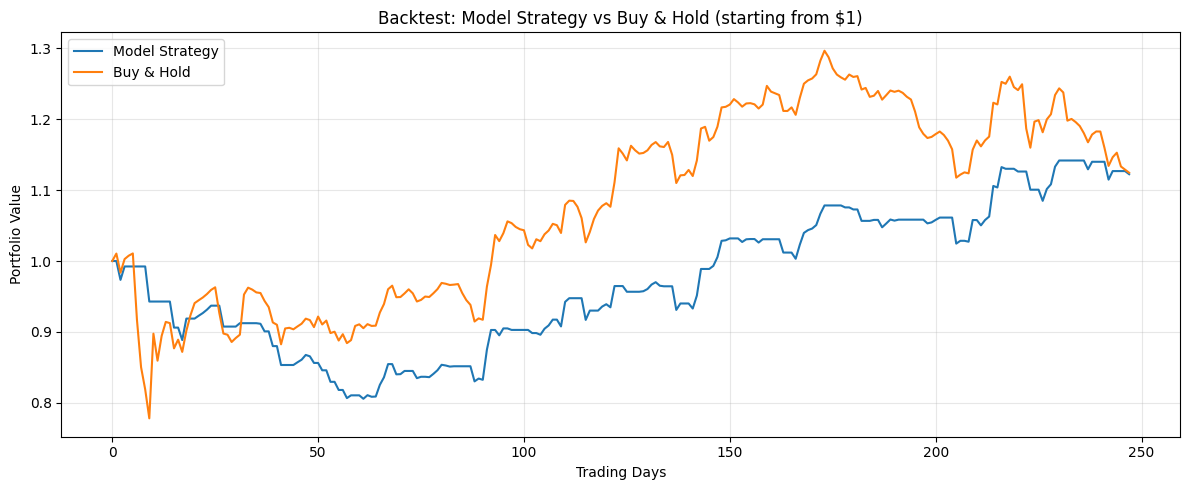

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(cumulative_strategy, label='Model Strategy', linewidth=1.5)
plt.plot(cumulative_bah, label='Buy & Hold', linewidth=1.5)
plt.title('Backtest: Model Strategy vs Buy & Hold (starting from $1)')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

| Metric | Value |
|---|---|
| Cross-val accuracy | ~47-53% |
| ROC-AUC | ~0.52 |
| Up precision | ~50% |
| Model vs Buy & Hold | Underperforms |

The model does not reliably beat the market. This is not a failure — it is the expected result
when predicting price direction from price history alone. The value of this project is in the pipeline:
feature engineering, proper evaluation with cross-validation, and backtesting against a benchmark.

These practices apply to any ML system, regardless of the problem domain.